In [14]:
# Import pandas, the main Python library we use for tables and CSV files.
import pandas as pd

# Read the uploaded CSV files into two tables called train_df and test_df.
train_df = pd.read_csv("train_dataset.csv")
test_df = pd.read_csv("test_dataset.csv")

print("Training data shape:", train_df.shape)
print("Test data shape:", test_df.shape)

print("\nTraining columns:")
print(train_df.columns.tolist())

print("\nTest columns:")
print(test_df.columns.tolist())


Training data shape: (150, 6)
Test data shape: (50, 5)

Training columns:
['flow_rate_L_min', 'concentration_mol_L', 'inlet_temperature_K', 'length_m', 'jacket_temperature_K', 'overall_yield']

Test columns:
['flow_rate_L_min', 'concentration_mol_L', 'inlet_temperature_K', 'length_m', 'jacket_temperature_K']


In [15]:
# Show the first five rows of the training data.
print("TRAINING DATA")
display(train_df.head())

# Show the first five rows of the test data.
print("TEST DATA")
display(test_df.head())


TRAINING DATA


,flow_rate_L_min,concentration_mol_L,inlet_temperature_K,length_m,jacket_temperature_K,overall_yield
0,33.09,3.68,357.75,19.87,383.79,63.024
1,76.30,1.34,429.70,14.84,405.72,86.611
2,59.90,1.01,431.10,11.76,385.40,86.347
3,49.90,2.21,445.61,22.85,367.74,92.175
4,16.70,3.95,458.91,4.56,374.13,82.211


TEST DATA


,flow_rate_L_min,concentration_mol_L,inlet_temperature_K,length_m,jacket_temperature_K
0,43.73,2.88,454.18,7.66,440.61
1,47.80,2.33,401.37,19.95,390.13
2,7.14,0.65,411.86,3.05,476.23
3,17.86,1.28,385.97,22.36,353.56
4,56.40,2.51,495.33,8.36,517.71


In [16]:
# Check whether any cells are empty.
print("Missing values in training data:")
print(train_df.isnull().sum())

print("\nMissing values in test data:")
print(test_df.isnull().sum())

# Check whether any complete rows are repeated.
print("\nDuplicate training rows:", train_df.duplicated().sum())
print("Duplicate test rows:", test_df.duplicated().sum())

# Display basic numerical statistics.
print("\nTraining data statistics:")
display(train_df.describe())


Missing values in training data:
flow_rate_L_min         0
concentration_mol_L     0
inlet_temperature_K     0
length_m                0
jacket_temperature_K    0
overall_yield           0
dtype: int64

Missing values in test data:
flow_rate_L_min         0
concentration_mol_L     0
inlet_temperature_K     0
length_m                0
jacket_temperature_K    0
dtype: int64

Duplicate training rows: 0
Duplicate test rows: 0

Training data statistics:


,flow_rate_L_min,concentration_mol_L,inlet_temperature_K,length_m,jacket_temperature_K,overall_yield
count,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000
mean,40.466800,2.311333,424.423400,14.086533,442.240800,36.222173
std,22.239772,1.019844,45.200641,6.995343,55.047768,38.427427
min,5.410000,0.520000,351.630000,2.260000,354.010000,0.000000
25%,21.112500,1.362500,387.255000,8.027500,393.327500,0.013500
50%,38.610000,2.445000,425.630000,14.235000,437.080000,15.314000
75%,61.227500,3.155000,462.972500,20.685000,486.180000,74.876500
max,79.020000,3.970000,498.580000,24.990000,547.990000,99.971000


In [17]:
# The target is the quantity we are trying to predict.
y = train_df["overall_yield"]

print("Minimum yield:", y.min())
print("Maximum yield:", y.max())
print("Average yield:", y.mean())
print("Median yield:", y.median())
print("Number of exactly-zero yields:", (y == 0).sum())


Minimum yield: 0.0
Maximum yield: 99.971
Average yield: 36.22217333333333
Median yield: 15.314
Number of exactly-zero yields: 37


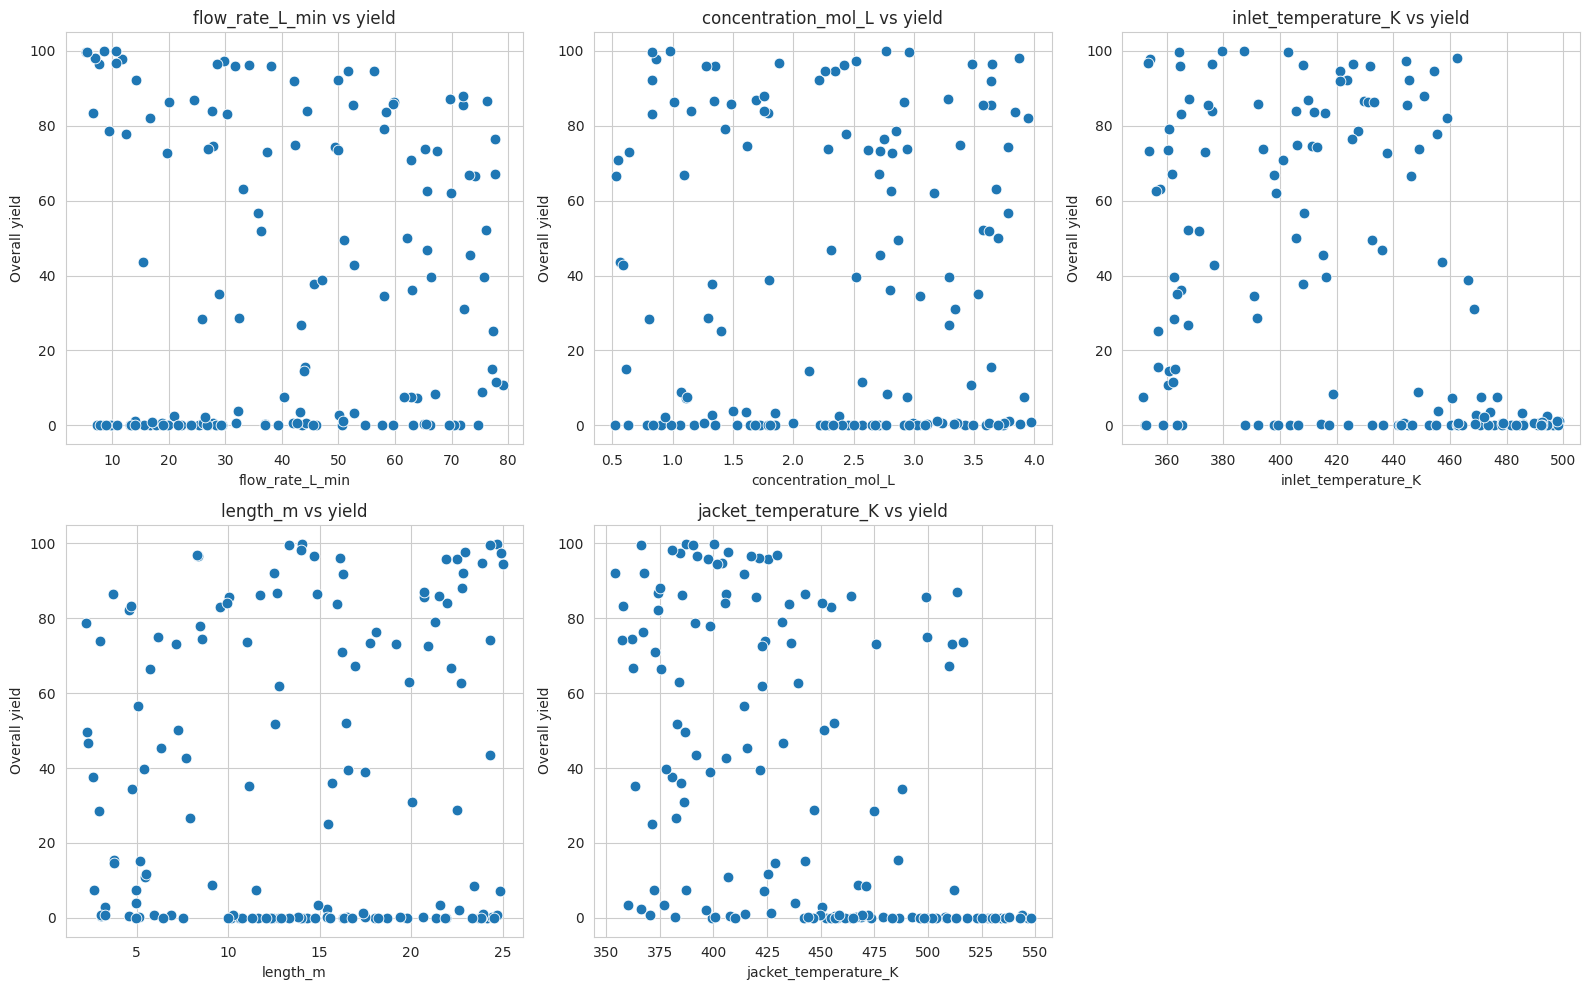

In [18]:
# Import plotting libraries.
import matplotlib.pyplot as plt
import seaborn as sns

# Make the graphs look cleaner.
sns.set_style("whitegrid")

# List of input columns.
feature_columns = [
    "flow_rate_L_min",
    "concentration_mol_L",
    "inlet_temperature_K",
    "length_m",
    "jacket_temperature_K"
]

# Create one graph for each input feature.
plt.figure(figsize=(16, 10))

for plot_number, feature in enumerate(feature_columns, start=1):
    plt.subplot(2, 3, plot_number)
    sns.scatterplot(
        data=train_df,
        x=feature,
        y="overall_yield",
        s=60
    )
    plt.title(f"{feature} vs yield")
    plt.xlabel(feature)
    plt.ylabel("Overall yield")

plt.tight_layout()
plt.show()


In [19]:
def create_features(dataframe):
    """Create extra features from the original reactor measurements."""

    # Make a copy so the original table is not accidentally changed.
    data = dataframe.copy()

    # A simple proxy for residence time.
    # Longer reactor and lower flow generally mean more time in the reactor.
    data["residence_time_proxy"] = data["length_m"] / data["flow_rate_L_min"]

    # Difference between the heating jacket and the incoming feed.
    data["temperature_difference"] = (
        data["jacket_temperature_K"] - data["inlet_temperature_K"]
    )

    # Average of the inlet and jacket temperatures.
    data["mean_temperature"] = (
        data["jacket_temperature_K"] + data["inlet_temperature_K"]
    ) / 2

    # Interaction features: these combine reaction time, temperature, and concentration.
    data["thermal_residence"] = (
        data["mean_temperature"] * data["residence_time_proxy"]
    )

    data["concentration_residence"] = (
        data["concentration_mol_L"] * data["residence_time_proxy"]
    )

    # Absolute temperature difference, regardless of which temperature is higher.
    data["absolute_temperature_difference"] = abs(
        data["temperature_difference"]
    )

    return data

# Create the new versions of the training and test tables.
train_feature_df = create_features(train_df)
test_feature_df = create_features(test_df)

print("Original number of columns:", train_df.shape[1])
print("New number of columns:", train_feature_df.shape[1])

# Display a few rows so you can see the added columns.
display(train_feature_df.head())


Original number of columns: 6
New number of columns: 12


,flow_rate_L_min,concentration_mol_L,inlet_temperature_K,length_m,jacket_temperature_K,overall_yield,residence_time_proxy,temperature_difference,mean_temperature,thermal_residence,concentration_residence,absolute_temperature_difference
0,33.09,3.68,357.75,19.87,383.79,63.024,0.600484,26.04,370.770,222.641278,2.209779,26.04
1,76.30,1.34,429.70,14.84,405.72,86.611,0.194495,-23.98,417.710,81.242679,0.260624,23.98
2,59.90,1.01,431.10,11.76,385.40,86.347,0.196327,-45.70,408.250,80.150584,0.198290,45.70
3,49.90,2.21,445.61,22.85,367.74,92.175,0.457916,-77.87,406.675,186.222921,1.011994,77.87
4,16.70,3.95,458.91,4.56,374.13,82.211,0.273054,-84.78,416.520,113.732407,1.078563,84.78


In [20]:
# Remove the answer column from the input data.
# The model must learn to predict this column, not use it as an input.
X = train_feature_df.drop(columns=["overall_yield"])
y = train_feature_df["overall_yield"]

# The test file never had an answer column, so all of its columns are inputs.
X_test = test_feature_df.copy()

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)
print("Shape of X_test:", X_test.shape)

print("\nInput columns used by the model:")
print(X.columns.tolist())


Shape of X: (150, 11)
Shape of y: (150,)
Shape of X_test: (50, 11)

Input columns used by the model:
['flow_rate_L_min', 'concentration_mol_L', 'inlet_temperature_K', 'length_m', 'jacket_temperature_K', 'residence_time_proxy', 'temperature_difference', 'mean_temperature', 'thermal_residence', 'concentration_residence', 'absolute_temperature_difference']


In [21]:
# Import tools for splitting data and calculating RMSE.
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import mean_squared_error

# Import several beginner-friendly regression models.
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor, RandomForestRegressor

# Make five repeatable folds.
# shuffle=True mixes the rows before splitting them.
# random_state=42 makes the result repeatable.
kfold = KFold(n_splits=5, shuffle=True, random_state=42)


In [22]:
# Create a collection of models.
# The dummy model is only a baseline: it predicts the average yield every time.
models = {
    "Baseline average": DummyRegressor(strategy="mean"),
    "Linear regression": LinearRegression(),
    "Random forest": RandomForestRegressor(
        n_estimators=400,
        max_features=0.8,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    ),
    "Extra trees": ExtraTreesRegressor(
        n_estimators=400,
        max_features=0.9,
        min_samples_leaf=1,
        random_state=42,
        n_jobs=-1
    ),
    "Gradient boosting": GradientBoostingRegressor(
        n_estimators=250,
        learning_rate=0.03,
        max_depth=2,
        min_samples_leaf=3,
        loss="huber",
        random_state=42
    )
}

results = []

for model_name, model in models.items():
    # sklearn's scoring uses negative RMSE, so we multiply by -1.
    scores = cross_val_score(
        model,
        X,
        y,
        cv=kfold,
        scoring="neg_root_mean_squared_error"
    )

    rmse_scores = -scores

    results.append({
        "Model": model_name,
        "Average RMSE": rmse_scores.mean(),
        "RMSE variation": rmse_scores.std()
    })

results_df = pd.DataFrame(results).sort_values("Average RMSE")
display(results_df)


,Model,Average RMSE,RMSE variation
3,Extra trees,17.569821,2.480494
2,Random forest,19.761179,2.121676
4,Gradient boosting,22.327982,1.862115
1,Linear regression,32.166618,1.614143
0,Baseline average,38.248370,3.569177


In [23]:
# Get the name of the best model from the validation table.
best_model_name = results_df.iloc[0]["Model"]
best_model = models[best_model_name]

print("Best model according to cross-validation:", best_model_name)
print("Validation RMSE:", round(results_df.iloc[0]["Average RMSE"], 3))

# Show the RMSE from each individual fold.
fold_scores = -cross_val_score(
    best_model,
    X,
    y,
    cv=kfold,
    scoring="neg_root_mean_squared_error"
)

print("RMSE in each fold:", fold_scores.round(3))
print("Average RMSE:", round(fold_scores.mean(), 3))


Best model according to cross-validation: Extra trees
Validation RMSE: 17.57
RMSE in each fold: [17.447 19.364 20.8   13.525 16.713]
Average RMSE: 17.57


In [24]:
# Create a fresh Extra Trees model using the same settings that we tested.
final_model = ExtraTreesRegressor(
    n_estimators=400,
    max_features=0.9,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

# Train the model on every available training row.
final_model.fit(X, y)

# Predict the yield for all 50 rows in the test file.
test_predictions = final_model.predict(X_test)

# Yield is a percentage, so keep predictions within the physical range 0 to 100.
test_predictions = test_predictions.clip(0, 100)

print("Number of predictions:", len(test_predictions))
print("First 10 predictions:")
print(test_predictions[:10].round(3))
print("Minimum prediction:", test_predictions.min())
print("Maximum prediction:", test_predictions.max())


Number of predictions: 50
First 10 predictions:
[18.526 82.257 25.412 82.07   0.776 58.971 78.143 68.73   3.953 52.449]
Minimum prediction: 0.039412499999999996
Maximum prediction: 84.41006750000001


In [25]:
# Create a submission DataFrame with exactly one required column.
submission_df = pd.DataFrame({
    "overall_yield": test_predictions
})

# Round to three decimal places as required by the hackathon.
submission_df["overall_yield"] = submission_df["overall_yield"].round(3)

# Verify that the submission has exactly the required shape and header.
print("Submission shape:", submission_df.shape)
print("Submission columns:", submission_df.columns.tolist())
display(submission_df.head(10))


Submission shape: (50, 1)
Submission columns: ['overall_yield']


,overall_yield
0,18.526
1,82.257
2,25.412
3,82.070
4,0.776
5,58.971
6,78.143
7,68.730
8,3.953
9,52.449


In [26]:
# Change this to your actual team name.
team_name = "hirenbvala321"

# Build the required filename.
submission_filename = f"{team_name}.csv"

# index=False is very important: it prevents an unwanted extra column.
submission_df.to_csv(submission_filename, index=False)

print(f"Saved submission file as: {submission_filename}")

# Read the saved file back and verify it one final time.
check_df = pd.read_csv(submission_filename)

print("Final file shape:", check_df.shape)
print("Final file columns:", check_df.columns.tolist())
print("Missing values:", check_df.isnull().sum().sum())
print("First five saved predictions:")
display(check_df.head())


Saved submission file as: hirenbvala321.csv
Final file shape: (50, 1)
Final file columns: ['overall_yield']
Missing values: 0
First five saved predictions:


,overall_yield
0,18.526
1,82.257
2,25.412
3,82.070
4,0.776
